In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
# cargamos el dataset completo
df = pd.read_csv("../data/citas_clinica_completo.csv")

df.head()

,id_cita,id_paciente,edad,genero,ocupacion,motivo_consulta,nivel_urgencia,fecha_solicitud,fecha_cita,dias_espera,dia_semana,franja_horaria,modalidad,canal_reserva,recordatorio_enviado,estado_cita,num_sesion,continuidad,satisfaccion
0,C00001,P0016,43,Mujer,Empleado/a,Estrés laboral,Medio,2025-01-26,2025-02-09,14,Domingo,Tarde,Online,Email,Sí,Asistida,1,Continúa,4
1,C00002,P0316,46,Mujer,Empleado/a,Estrés académico,Medio,2024-09-08,2024-09-22,14,Domingo,Mañana,Online,WhatsApp,Sí,Asistida,1,Continúa,3
2,C00003,P0270,49,Mujer,Empleado/a,Autoestima,Medio,2024-09-12,2024-09-26,14,Jueves,Noche,Presencial,Teléfono,Sí,Asistida,1,Continúa,5
3,C00004,P0177,70,Hombre,Jubilado/a,Estrés laboral,Alto,2025-08-02,2025-08-07,5,Jueves,Mañana,Online,Teléfono,Sí,Asistida,1,Abandona,2
4,C00005,P0242,49,Hombre,Empleado/a,Estrés laboral,Medio,2025-06-26,2025-07-05,9,Sábado,Tarde,Presencial,Email,Sí,Asistida,1,Continúa,5


REvisamos información general 

In [3]:
df. info ()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1600 entries, 0 to 1599
Data columns (total 19 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   id_cita               1600 non-null   object
 1   id_paciente           1600 non-null   object
 2   edad                  1600 non-null   int64 
 3   genero                1600 non-null   object
 4   ocupacion             1600 non-null   object
 5   motivo_consulta       1600 non-null   object
 6   nivel_urgencia        1600 non-null   object
 7   fecha_solicitud       1600 non-null   object
 8   fecha_cita            1600 non-null   object
 9   dias_espera           1600 non-null   int64 
 10  dia_semana            1600 non-null   object
 11  franja_horaria        1600 non-null   object
 12  modalidad             1600 non-null   object
 13  canal_reserva         1600 non-null   object
 14  recordatorio_enviado  1600 non-null   object
 15  estado_cita           1600 non-null   

In [4]:
# cambiamos fechas a formato datetime
df["fecha_solicitud"] = pd.to_datetime(df["fecha_solicitud"])
df["fecha_cita"] = pd.to_datetime(df["fecha_cita"])

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1600 entries, 0 to 1599
Data columns (total 19 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   id_cita               1600 non-null   object        
 1   id_paciente           1600 non-null   object        
 2   edad                  1600 non-null   int64         
 3   genero                1600 non-null   object        
 4   ocupacion             1600 non-null   object        
 5   motivo_consulta       1600 non-null   object        
 6   nivel_urgencia        1600 non-null   object        
 7   fecha_solicitud       1600 non-null   datetime64[ns]
 8   fecha_cita            1600 non-null   datetime64[ns]
 9   dias_espera           1600 non-null   int64         
 10  dia_semana            1600 non-null   object        
 11  franja_horaria        1600 non-null   object        
 12  modalidad             1600 non-null   object        
 13  canal_reserva     

In [6]:
df. shape 

(1600, 19)

In [7]:
df.isnull().sum()

id_cita                 0
id_paciente             0
edad                    0
genero                  0
ocupacion               0
motivo_consulta         0
nivel_urgencia          0
fecha_solicitud         0
fecha_cita              0
dias_espera             0
dia_semana              0
franja_horaria          0
modalidad               0
canal_reserva           0
recordatorio_enviado    0
estado_cita             0
num_sesion              0
continuidad             0
satisfaccion            0
dtype: int64

In [8]:
df.duplicated().sum()

np.int64(0)

Resumen numérico 

In [9]:
df. describe()

,edad,fecha_solicitud,fecha_cita,dias_espera,num_sesion,satisfaccion
count,1600.000000,1600,1600,1600.000000,1600.000000,1600.000000
mean,47.683750,2025-01-06 11:25:47.999999744,2025-01-18 01:41:42,11.793125,3.011875,3.428750
min,18.000000,2024-01-01 00:00:00,2024-01-03 00:00:00,1.000000,1.000000,1.000000
25%,34.000000,2024-07-01 00:00:00,2024-07-12 18:00:00,6.000000,2.000000,3.000000
50%,49.000000,2025-01-20 00:00:00,2025-01-30 00:00:00,10.000000,3.000000,4.000000
75%,63.000000,2025-07-13 00:00:00,2025-07-21 00:00:00,15.000000,4.000000,4.000000
max,75.000000,2025-12-31 00:00:00,2025-12-31 00:00:00,30.000000,11.000000,5.000000
std,16.953639,NaN,NaN,7.265041,1.832371,1.205542


## Análisis exploratorio de datos

En esta fase se analiza el dataset completo de citas de la clínica psicológica ficticia CliniMind.  
El objetivo es entender la distribución de pacientes, citas, motivos de consulta, asistencia, cancelaciones, recordatorios y continuidad terapéutica.

# BLOQUE 1: ANÁLISIS GENERAL DE LA CLÍNICA 

In [10]:
# TOTAL DE CITAS
total_citas= len (df)
total_citas

1600

In [11]:
# TOTAL DE PACIENTES ÚNICOS
total_pacientes = df["id_paciente"].nunique()
total_pacientes

392

In [12]:
# PERIODO ANALIZADO 
fecha_min= df["fecha_cita"].min()
fecha_max= df["fecha_cita"].max()

fecha_min, fecha_max

(Timestamp('2024-01-03 00:00:00'), Timestamp('2025-12-31 00:00:00'))

In [13]:
# EDAD MEDIA DE LOS PACIENTES
edad_media = df["edad"].mean().round(2)
edad_media

np.float64(47.68)

In [14]:
# DIAS MEDIOS DE ESPERA
espera_media = df["dias_espera"].mean().round(2)
espera_media

np.float64(11.79)

In [15]:
# SATISFACIÓN MEDIA DE LOS PACIENTES
satisfaccion_media = df["satisfaccion"].mean().round(2)
satisfaccion_media

np.float64(3.43)

In [16]:
# CREAMOS UNA TABLA RESUMEN CON LOS INDICADORES CALCULADOS
resumen_general = pd.DataFrame(
    {
        "Indicador": [
            "Total de citas",
            "Pacientes únicos",
            "Fecha mínima",
            "Fecha máxima",
            "Edad media",
            "Días medios de espera",
            "Satisfacción media",
        ],
        "Valor": [
            total_citas,
            total_pacientes,
            fecha_min,
            fecha_max,
            edad_media,
            espera_media,
            satisfaccion_media,
        ],
    }
)

resumen_general

,Indicador,Valor
0,Total de citas,1600
1,Pacientes únicos,392
2,Fecha mínima,2024-01-03 00:00:00
3,Fecha máxima,2025-12-31 00:00:00
4,Edad media,47.68
5,Días medios de espera,11.79
6,Satisfacción media,3.43


## Resumen general

El dataset contiene 1.600 citas correspondientes a pacientes atendidos entre enero de 2024 y diciembre de 2025.  
Este primer resumen permite conocer el volumen total de actividad, el número de pacientes únicos, la edad media, el tiempo medio de espera hasta la cita y la satisfacción media registrada.

Estos indicadores funcionan como una primera visión global de la actividad de la clínica.

# BLOQUE 2: ANÁLISIS DE ASISTENCIA Y CANCELACIONES
La pregunta que queremos responder es:

¿Qué porcentaje de citas fueron asistidas, canceladas, no asistidas o reprogramadas?

In [ ]:
# CONTEO DE ESTADO DE CITA
df["estado_cita"].value_counts()

estado_cita
Asistida        1172
Cancelada        198
No asistida      129
Reprogramada     101
Name: count, dtype: int64

In [ ]:
#porcentaje de cada estado
estado_cita_porcentaje = df["estado_cita"].value_counts(normalize=True).round(4) * 100
estado_cita_porcentaje= estado_cita_porcentaje. round(2)
estado_cita_porcentaje

estado_cita
Asistida        73.25
Cancelada       12.38
No asistida      8.06
Reprogramada     6.31
Name: proportion, dtype: float64

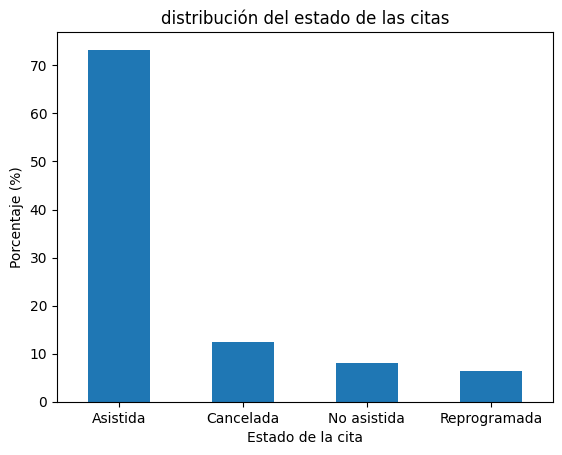

In [ ]:
# Gráfico de barras para estado de cita
estado_cita_porcentaje.plot(kind="bar")

plt.title("distribución del estado de las citas")
plt.xlabel("Estado de la cita")
plt.ylabel("Porcentaje (%)")
plt.xticks
plt.show()

## Estado de las citas

Este análisis muestra la distribución de las citas según su estado final: asistidas, canceladas, no asistidas o reprogramadas.

La tasa de asistencia permite valorar el funcionamiento general de la agenda clínica, mientras que las cancelaciones y no asistencias son indicadores relevantes para la gestión administrativa y la optimización de recursos.

En el contexto del secretariado médico, estos resultados pueden ayudar a identificar oportunidades de mejora en la comunicación con pacientes, la gestión de recordatorios y la organización de la agenda.

In [21]:
# INDICADORES CONCRETOS
tasa_asistencia = estado_cita_porcentaje.get("Asistida", 0)
tasa_cancelacion = estado_cita_porcentaje.get("Cancelada", 0)
tasa_no_asistencia = estado_cita_porcentaje.get("No asistida", 0)
tasa_reprogramacion = estado_cita_porcentaje.get("Reprogramada", 0)

tasa_asistencia, tasa_cancelacion, tasa_no_asistencia, tasa_reprogramacion

(np.float64(73.25), np.float64(12.38), np.float64(8.06), np.float64(6.31))

In [23]:
# CREAMOS TABLA CON LOS INDICADORES
indicadores_citas = pd.DataFrame(
    {"Indicador": ["Tasa de asistencia","Tasa de cancelación","Tasa de no asistencia","Tasa de reprogramación",],
    "Porcentaje": [tasa_asistencia,tasa_cancelacion,tasa_no_asistencia,tasa_reprogramacion,],})

indicadores_citas

,Indicador,Porcentaje
0,Tasa de asistencia,73.25
1,Tasa de cancelación,12.38
2,Tasa de no asistencia,8.06
3,Tasa de reprogramación,6.31


# BLOQUE 3: RECORDATORIOS Y ASISTENCIA
¿Enviar recordatorios está relacionado con una mayor asistencia y menos no asistencia?

In [ ]:
# CONTEO DE RECORDATORIOS ENVIADOS
df["recordatorio_enviado"].value_counts()

recordatorio_enviado
Sí    1185
No     415
Name: count, dtype: int64

In [25]:
#PORCENTAJE DE RECORDATORIOS ENVIADOS
recordatorio_porcentaje = df["recordatorio_enviado"].value_counts(normalize=True).round(4) * 100
recordatorio_porcentaje= recordatorio_porcentaje.round(2)
recordatorio_porcentaje

recordatorio_enviado
Sí    74.06
No    25.94
Name: proportion, dtype: float64

In [26]:
# HACEMOS UNA TABLA CRUZADA: RECORDATORIO ENVIADO VS ESTADO DE CITA
recordatorio_estado= pd. crosstab(df["recordatorio_enviado"], df["estado_cita"], normalize="index") * 100
recordatorio_estado= recordatorio_estado.round(2)
recordatorio_estado

estado_cita,Asistida,Cancelada,No asistida,Reprogramada
recordatorio_enviado,,,,
No,60.48,16.39,17.11,6.02
Sí,77.72,10.97,4.89,6.41


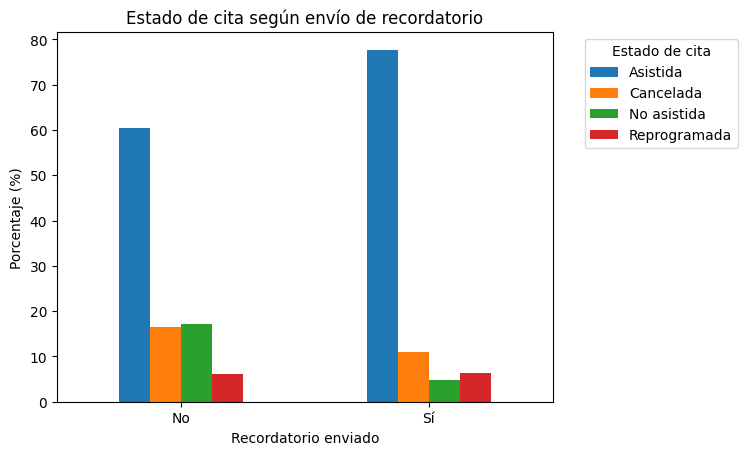

In [27]:
# GRAFICO 
recordatorio_estado.plot(kind= "bar")

plt.title("Estado de cita según envío de recordatorio")
plt.xlabel("Recordatorio enviado")
plt.ylabel("Porcentaje (%)")
plt.xticks(rotation=0)
plt.legend(title="Estado de cita", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.show()

## Recordatorios y asistencia

Este análisis compara el estado final de las citas en función de si se envió o no un recordatorio previo.

El objetivo es valorar si los recordatorios podrían estar asociados con una mayor tasa de asistencia y una menor tasa de no asistencia. Desde la perspectiva del secretariado médico, este resultado puede ser útil para justificar la automatización de recordatorios por WhatsApp, email o llamada telefónica.

Aunque el dataset es sintético, el análisis reproduce una situación habitual en centros sanitarios: reducir ausencias y mejorar la eficiencia de la agenda clínica.

# BLOQUE 4: MOTIVO DE CONSULTA 

In [30]:
# CONTEO DE MOTIVOS DE CONSULTA
df["motivo_consulta"].value_counts()

motivo_consulta
Ansiedad                342
Estrés laboral          268
Duelo                   254
Orientación familiar    174
Depresión leve          169
Autoestima              164
Problemas de pareja     131
Estrés académico         98
Name: count, dtype: int64

In [31]:
# PORCENTAJE DE MOTIVOS DE CONSULTA
motivo_porcentaje = df["motivo_consulta"].value_counts(normalize=True).round(4) * 100
motivo_porcentaje = motivo_porcentaje.round(2)
motivo_porcentaje

motivo_consulta
Ansiedad                21.38
Estrés laboral          16.75
Duelo                   15.88
Orientación familiar    10.88
Depresión leve          10.56
Autoestima              10.25
Problemas de pareja      8.19
Estrés académico         6.12
Name: proportion, dtype: float64

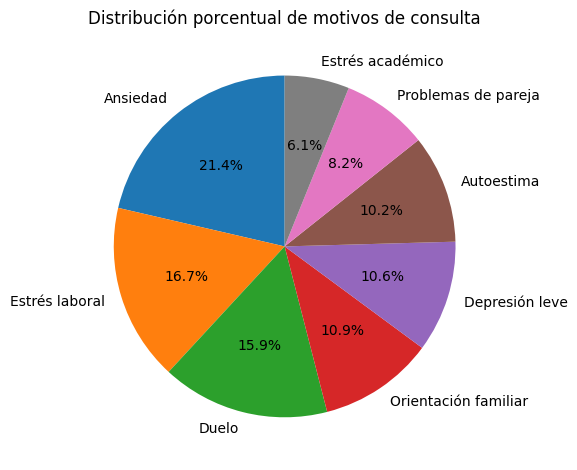

In [33]:
# GRAFICO DE MOTIVOS DE CONSULTA
motivo_porcentaje.plot(kind="pie", autopct="%1.1f%%", startangle=90)

plt.title("Distribución porcentual de motivos de consulta")
plt.ylabel("")
plt.tight_layout()
plt.show()

### CRUZAR EL MOTIVO DE CONSULTA CON NIVEL DE URGENCIA 
¿Qué motivos de consulta aparecen más asociados a urgencia baja, media o alta?

In [34]:
motivo_urgencia = (
    pd.crosstab(df["motivo_consulta"], df["nivel_urgencia"], normalize="index") * 100)
motivo_urgencia = motivo_urgencia.round(2)
motivo_urgencia

nivel_urgencia,Alto,Bajo,Medio
motivo_consulta,,,
Ansiedad,24.27,15.20,60.53
Autoestima,20.12,44.51,35.37
Depresión leve,18.34,17.16,64.50
Duelo,23.62,34.25,42.13
Estrés académico,18.37,30.61,51.02
Estrés laboral,11.94,49.25,38.81
Orientación familiar,10.34,55.75,33.91
Problemas de pareja,10.69,57.25,32.06


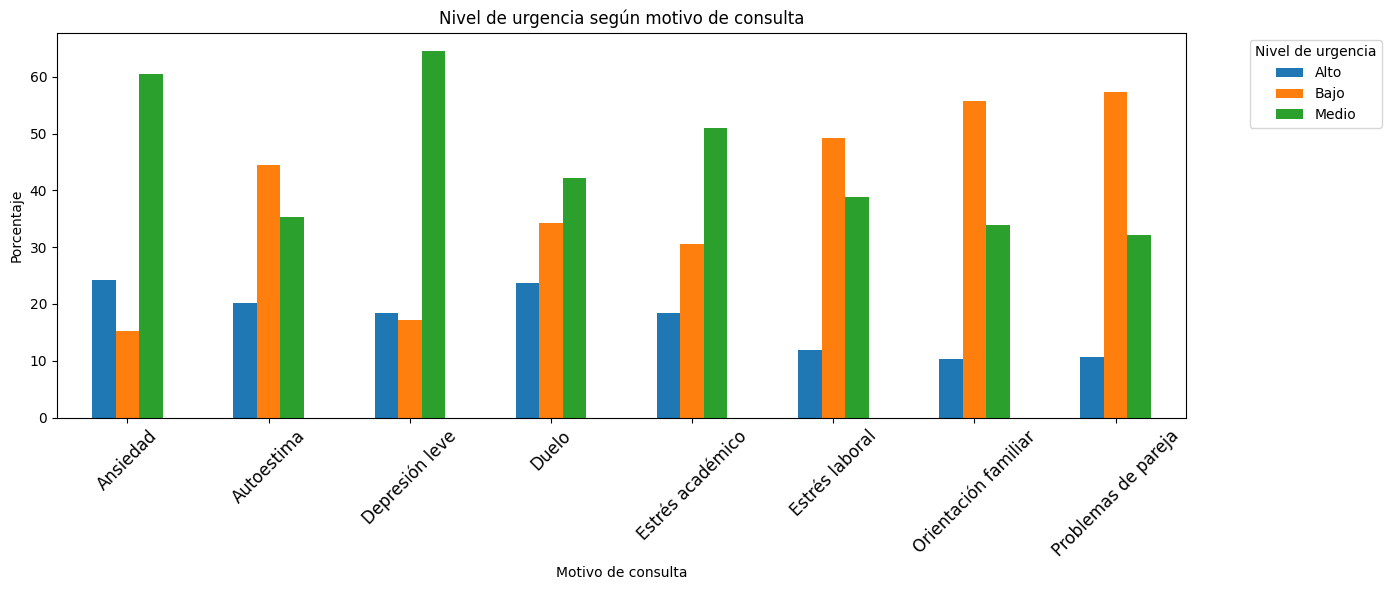

In [46]:
# GRAFICO DE MOTIVO CONSULTA VS NIVEL DE URGENCIA

motivo_urgencia.plot(kind="bar",figsize=(14, 6))

plt.title("Nivel de urgencia según motivo de consulta")
plt.xlabel("Motivo de consulta")
plt.ylabel("Porcentaje")
plt.xticks(rotation=45, fontsize=12)
plt.legend(title="Nivel de urgencia", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

## Motivos de consulta y nivel de urgencia

Este análisis permite observar cómo se distribuyen los niveles de urgencia según el motivo principal de consulta.

Desde la perspectiva psicológica, esta información ayuda a identificar qué demandas pueden requerir una atención más prioritaria. Desde la perspectiva del secretariado médico, puede ser útil para organizar la agenda, priorizar primeras citas y mejorar la planificación de recursos.

Al tratarse de un dataset sintético, los resultados no representan evidencia clínica real, sino una simulación útil para practicar análisis de datos aplicado a una clínica psicológica.

# BLOQUE 5: ANÁLISIS DE CONTINUIDAD TERAPÉUTICA 
¿Qué porcentaje de pacientes continúa, abandona, recibe alta terapéutica o es derivado?

In [47]:
# CONTEO DE CONTINUIDAD
df["continuidad"].value_counts()

continuidad
Continúa            1057
Abandona             330
Alta terapéutica     110
Derivación           103
Name: count, dtype: int64

In [48]:
# PORCENTAJE DE CONTINUIDAD
continuidad_porcentaje = df["continuidad"].value_counts(normalize=True).round(4) * 100
continuidad_porcentaje = continuidad_porcentaje.round(2)
continuidad_porcentaje

continuidad
Continúa            66.06
Abandona            20.62
Alta terapéutica     6.88
Derivación           6.44
Name: proportion, dtype: float64

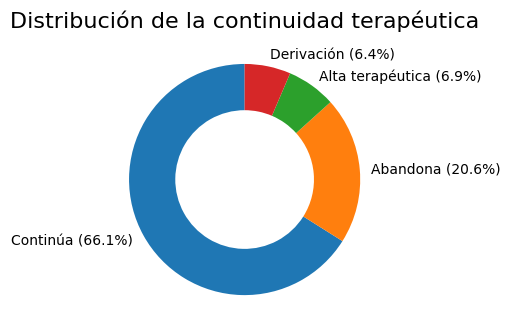

In [51]:
# GRÁFICO
etiquetas = [
    f"{nombre} ({valor:.1f}%)" for nombre, valor in continuidad_porcentaje.items()
]

continuidad_porcentaje.plot(kind="pie", labels= etiquetas,startangle=90, figsize=(5, 5),wedgeprops={"width": 0.4},)

plt.title("Distribución de la continuidad terapéutica", fontsize=16)
plt.ylabel("")
plt.tight_layout()
plt.show()

## Continuidad terapéutica

Este análisis muestra la distribución de los procesos terapéuticos según su estado de continuidad: pacientes que continúan, abandonan, reciben alta terapéutica o son derivados a otro recurso.

Desde la perspectiva psicológica, la continuidad terapéutica es un indicador relevante para estudiar la adherencia al tratamiento. Desde la perspectiva administrativa, permite detectar posibles puntos de mejora en el seguimiento de pacientes y en la gestión de citas.

Al tratarse de un dataset sintético, los resultados deben interpretarse como una simulación para practicar análisis de datos en un contexto sanitario.

## cruzamos continuidad con días de espera
¿Los pacientes que abandonan tuvieron más días de espera antes de la cita?

In [52]:
# tabla resumen 
df.groupby("continuidad")["dias_espera"].describe().round(2)


,count,mean,std,min,25%,50%,75%,max
continuidad,,,,,,,,
Abandona,330.0,11.27,7.02,1.0,6.0,10.0,15.0,30.0
Alta terapéutica,110.0,12.09,7.46,1.0,7.0,11.0,15.0,30.0
Continúa,1057.0,11.86,7.27,1.0,6.0,10.0,15.0,30.0
Derivación,103.0,12.44,7.78,1.0,6.0,11.0,16.0,30.0


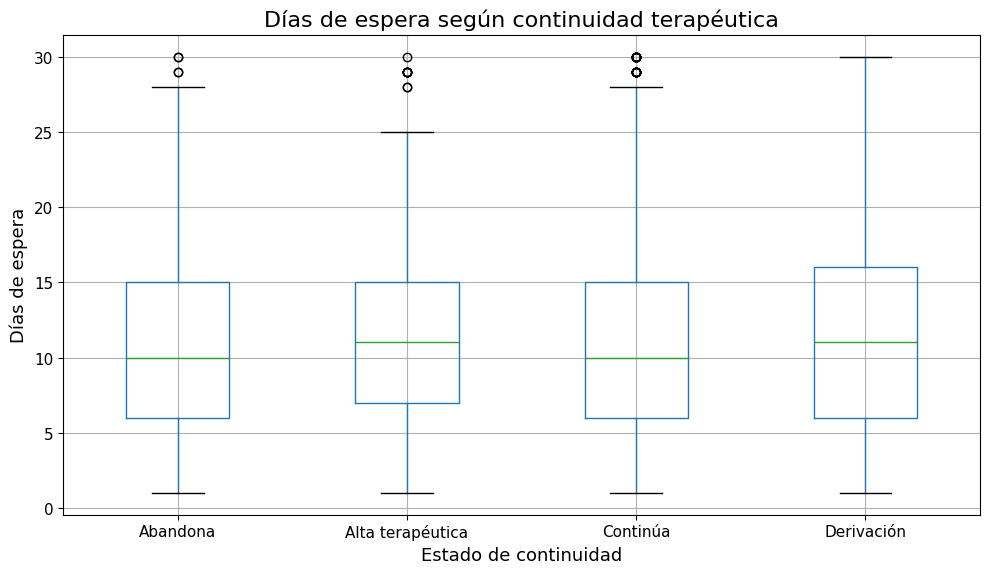

In [54]:
# grafico días de espera seún continuidad
df.boxplot(column="dias_espera", by="continuidad", figsize=(10, 6))

plt.title("Días de espera según continuidad terapéutica", fontsize=16)
plt.suptitle("")
plt.xlabel("Estado de continuidad", fontsize=13)
plt.ylabel("Días de espera", fontsize=13)
plt.xticks(rotation=0, fontsize=11)
plt.yticks(fontsize=11)
plt.tight_layout()
plt.show()

### Continuidad terapéutica y días de espera

Este análisis compara los días de espera hasta la cita según el estado de continuidad terapéutica.

El objetivo es explorar si los tiempos de espera más largos podrían estar asociados con una mayor probabilidad de abandono. Desde la gestión administrativa, este indicador es relevante porque permite valorar si reducir el tiempo entre la solicitud y la cita podría mejorar la adherencia al proceso terapéutico.

El gráfico de caja permite observar la distribución de los días de espera en cada grupo de continuidad, incluyendo la mediana, la dispersión y posibles valores extremos.